In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [2]:
SCALED_CSV = "../data/processed/bangalore_traffic_scaled.csv"
PROCESSED_CSV = "../data/processed/bangalore_traffic_processed.csv"   # unscaled, human-readable
OUTPUT_WITH_CLUSTERS = "../data/processed/bangalore_traffic_with_clusters_k4.csv"
OUTPUT_SCENARIOS = "../data/processed/traffic_scenarios_from_clusters_k4.csv"

In [3]:
X_scaled = pd.read_csv(SCALED_CSV)
print("Scaled data shape:", X_scaled.shape)


df_processed = pd.read_csv(PROCESSED_CSV)
print("Processed (unscaled) data shape:", df_processed.shape)

X_scaled.head()

Scaled data shape: (8936, 14)
Processed (unscaled) data shape: (8936, 14)


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Pedestrian and Cyclist Count,IsWeekend,Weather Conditions_Fog,Weather Conditions_Overcast,Weather Conditions_Rain,Weather Conditions_Windy,Roadwork and Construction Activity_Yes
0,1.642475,1.007120,0.752807,0.815148,0.480677,-1.105933,1.642475,-0.095987,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
1,0.122217,-0.940566,0.752807,0.815148,0.480677,-0.401692,0.122217,-0.394815,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
2,-1.679633,1.403518,-2.035479,-2.229745,-3.354921,-1.105933,-1.679633,2.022972,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
3,2.433486,0.408175,0.752807,0.815148,0.480677,-0.401692,2.433486,-0.095987,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924
4,2.157971,0.155916,0.752807,0.815148,0.480677,1.006791,2.157971,-0.286151,1.577308,-0.346728,-0.411866,-0.319352,-0.224289,-0.330924


In [4]:
K_FINAL = 4

# Convert to numpy array for KMeans
X = X_scaled.values

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(X)

sil = silhouette_score(X, cluster_labels)
print(f"Final KMeans model trained with k={K_FINAL}")
print(f"Silhouette Score: {sil:.4f}")


cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nSamples per cluster:")
print(cluster_counts)


c:\Users\Krishnendu Manna\anaconda3\envs\traffic-env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Final KMeans model trained with k=4
Silhouette Score: 0.2305

Samples per cluster:
0     818
1    1310
2    2155
3    4653
Name: count, dtype: int64


In [8]:
df_with_clusters = df_processed.copy()
df_with_clusters["cluster"] = cluster_labels

df_with_clusters.to_csv(OUTPUT_WITH_CLUSTERS, index=False)
print(f"✔ Saved data with cluster labels to: {OUTPUT_WITH_CLUSTERS}")

df_with_clusters.head()


✔ Saved data with cluster labels to: ../data/processed/bangalore_traffic_with_clusters_k4.csv


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Pedestrian and Cyclist Count,IsWeekend,Weather Conditions_Fog,Weather Conditions_Overcast,Weather Conditions_Rain,Weather Conditions_Windy,Roadwork and Construction Activity_Yes,cluster
0,50590.0,50.230299,1.500000,100.000000,100.000000,0.0,151.180,111.0,1.0,0.0,0.0,0.0,0.0,0.0,3
1,30825.0,29.377125,1.500000,100.000000,100.000000,1.0,111.650,100.0,1.0,0.0,0.0,0.0,0.0,0.0,3
2,7399.0,54.474398,1.039069,28.347994,36.396525,0.0,64.798,189.0,1.0,0.0,0.0,0.0,0.0,0.0,1
3,60874.0,43.817610,1.500000,100.000000,100.000000,1.0,171.748,111.0,1.0,0.0,0.0,0.0,0.0,0.0,3
4,57292.0,41.116763,1.500000,100.000000,100.000000,3.0,164.584,104.0,1.0,0.0,0.0,0.0,0.0,0.0,3


In [6]:
centers_scaled = kmeans_final.cluster_centers_
centers_scaled_df = pd.DataFrame(centers_scaled, columns=X_scaled.columns)
centers_scaled_df


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Pedestrian and Cyclist Count,IsWeekend,Weather Conditions_Fog,Weather Conditions_Overcast,Weather Conditions_Rain,Weather Conditions_Windy,Roadwork and Construction Activity_Yes
0,0.226994,-0.095001,0.213102,0.344389,0.385002,0.161357,0.226994,-0.387343,0.017504,2.884101,-0.411866,-0.319352,-0.224289,-0.056309
1,-1.387861,0.515470,-1.055409,-1.855013,-2.181838,-0.730159,-1.387861,2.312385,0.012518,-0.018713,0.021698,0.012547,-0.013383,0.022268
2,-0.677265,0.530974,-1.055962,-0.537005,0.142627,-0.284482,-0.677265,-0.394954,-0.009661,-0.334746,0.027868,0.024598,0.014520,-0.010725
3,0.665078,-0.374729,0.749512,0.710961,0.480677,0.309212,0.665078,-0.400014,-0.002124,-0.346728,0.053402,0.041224,0.036483,0.008605


In [9]:
# Group by cluster and compute mean of important features in ORIGINAL units
important_cols = [
    'Traffic Volume',
    'Average Speed',
    'Travel Time Index',
    'Congestion Level',
    'Road Capacity Utilization',
    'Incident Reports',
    'Environmental Impact',
    'Pedestrian and Cyclist Count',
    'IsWeekend'
]

cluster_profiles = df_with_clusters.groupby("cluster")[important_cols].mean().round(2)
cluster_profiles


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Pedestrian and Cyclist Count,IsWeekend
cluster,,,,,,,,,
0,32187.22,38.43,1.41,88.92,98.41,1.80,114.37,100.28,0.29
1,11192.36,44.97,1.20,37.17,55.85,0.53,72.38,199.65,0.29
2,20425.34,45.13,1.20,68.16,94.39,1.17,90.85,100.00,0.28
3,37877.84,35.44,1.50,97.55,100.00,2.01,125.76,99.81,0.29


In [10]:
cluster_profiles["count"] = df_with_clusters["cluster"].value_counts().sort_index()
cluster_profiles["share_%"] = (cluster_profiles["count"] / len(df_with_clusters) * 100).round(2)

cluster_profiles


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Pedestrian and Cyclist Count,IsWeekend,count,share_%
cluster,,,,,,,,,,,
0,32187.22,38.43,1.41,88.92,98.41,1.80,114.37,100.28,0.29,818,9.15
1,11192.36,44.97,1.20,37.17,55.85,0.53,72.38,199.65,0.29,1310,14.66
2,20425.34,45.13,1.20,68.16,94.39,1.17,90.85,100.00,0.28,2155,24.12
3,37877.84,35.44,1.50,97.55,100.00,2.01,125.76,99.81,0.29,4653,52.07


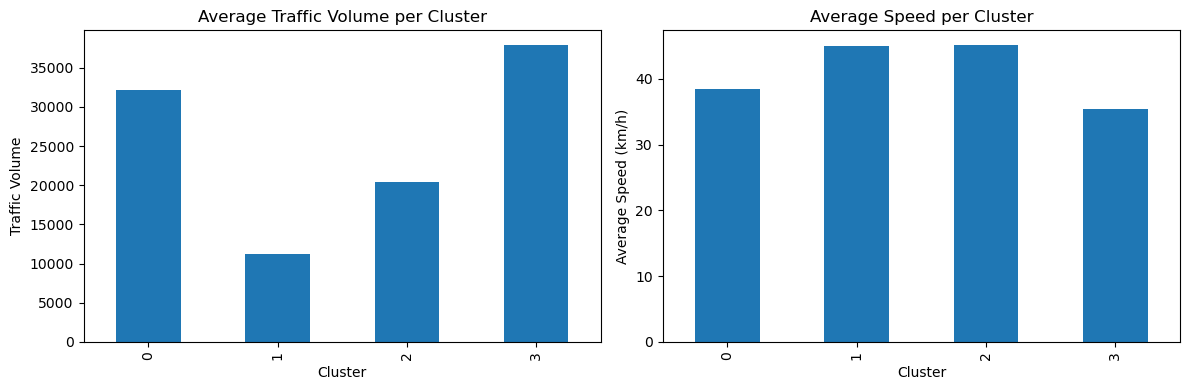

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

cluster_profiles["Traffic Volume"].plot(kind="bar", ax=ax[0])
ax[0].set_title("Average Traffic Volume per Cluster")
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Traffic Volume")

cluster_profiles["Average Speed"].plot(kind="bar", ax=ax[1])
ax[1].set_title("Average Speed per Cluster")
ax[1].set_xlabel("Cluster")
ax[1].set_ylabel("Average Speed (km/h)")

plt.tight_layout()
plt.show()


In [12]:
# Example – adjust based on cluster_profiles table
cluster_to_state = {
    0: "Free Flow",
    1: "Normal",
    2: "Peak Congestion",
    3: "Incident / Disrupted"
}

df_with_clusters["traffic_state"] = df_with_clusters["cluster"].map(cluster_to_state)
df_with_clusters[["cluster", "traffic_state"]].head()


,cluster,traffic_state
0,3,Incident / Disrupted
1,3,Incident / Disrupted
2,1,Normal
3,3,Incident / Disrupted
4,3,Incident / Disrupted


In [11]:
df_with_clusters.to_csv(OUTPUT_WITH_CLUSTERS, index=False)
print(f"✔ Updated file with traffic_state to: {OUTPUT_WITH_CLUSTERS}")


✔ Updated file with traffic_state to: ../data/processed/bangalore_traffic_with_clusters_k4.csv


Simulation Scenario Table from Clusters


In [13]:
scenarios = cluster_profiles.copy()

# Normalize some values into "simulation-scale" parameters
# You can tweak these mappings based on how your simulator works.

# Example: spawn_rate ~ scaled traffic volume
max_volume = scenarios["Traffic Volume"].max()
scenarios["spawn_rate"] = (scenarios["Traffic Volume"] / max_volume * 30).round(1)  # e.g. 0–30 vehicles per unit time

# Example: use Average Speed directly (or clip)
scenarios["sim_speed"] = scenarios["Average Speed"].round(1)

# Example: incident probability from Incident Reports
max_incidents = scenarios["Incident Reports"].max() if scenarios["Incident Reports"].max() > 0 else 1
scenarios["incident_prob"] = (scenarios["Incident Reports"] / max_incidents).round(2)

# Attach name using cluster_to_state (if defined)
if 'cluster_to_state' in globals():
    scenarios["traffic_state_name"] = scenarios.index.map(cluster_to_state)
else:
    scenarios["traffic_state_name"] = scenarios.index.astype(str)

# Reorder columns for clarity
scenarios_out = scenarios[[
    "traffic_state_name",
    "Traffic Volume",
    "Average Speed",
    "Congestion Level",
    "Road Capacity Utilization",
    "Incident Reports",
    "spawn_rate",
    "sim_speed",
    "incident_prob",
    "count",
    "share_%"
]].reset_index().rename(columns={"cluster": "cluster_id"})

scenarios_out


scenarios_out.to_csv(OUTPUT_SCENARIOS, index=False)
print(f"✔ Saved simulation scenarios table to: {OUTPUT_SCENARIOS}")
scenarios_out

✔ Saved simulation scenarios table to: ../data/processed/traffic_scenarios_from_clusters_k4.csv


,cluster_id,traffic_state_name,Traffic Volume,Average Speed,Congestion Level,Road Capacity Utilization,Incident Reports,spawn_rate,sim_speed,incident_prob,count,share_%
0,0,Free Flow,32187.22,38.43,88.92,98.41,1.80,25.5,38.4,0.90,818,9.15
1,1,Normal,11192.36,44.97,37.17,55.85,0.53,8.9,45.0,0.26,1310,14.66
2,2,Peak Congestion,20425.34,45.13,68.16,94.39,1.17,16.2,45.1,0.58,2155,24.12
3,3,Incident / Disrupted,37877.84,35.44,97.55,100.00,2.01,30.0,35.4,1.00,4653,52.07


In [1]:
import numpy as np
q = np.load("../results/trained_q_agent.npy")
q.shape


(40, 5)